In [1]:
import matplotlib.pyplot as plt 
import matplotlib.image as img
import numpy as np

Dimensão Imagem Azul:  (480, 640)
Dimensão Imagem Vermelho:  (480, 640)
Dimensão Imagem Amarelo:  (480, 640)
Dimensão Imagem Branca:  (480, 640)
Escala comum: vmin=0.0, vmax=1.0


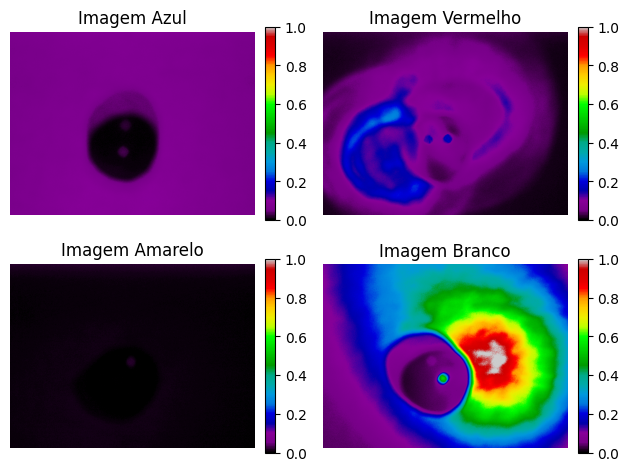

In [2]:
image_blue = img.imread('spectral_project/captures_test/captures_2025-08-12_14-47-32/blue_2025-08-12_14-47-32.png') 
image_red = img.imread('spectral_project/captures_test/captures_2025-08-12_14-47-32/red_2025-08-12_14-47-32.png') 
image_yellow = img.imread('spectral_project/captures_test/captures_2025-08-12_14-47-32/yellow_2025-08-12_14-47-32.png')
image_white = img.imread('spectral_project/captures_test/captures_2025-08-12_14-47-32/white_2025-08-12_14-47-32.png')

# nipy_spectral is indicate to spectral_images and viridis is the default method
plt.set_cmap('nipy_spectral')

print("Dimensão Imagem Azul: ", image_blue.shape)
print("Dimensão Imagem Vermelho: ", image_red.shape)
print("Dimensão Imagem Amarelo: ", image_yellow.shape)
print("Dimensão Imagem Branca: ", image_white.shape)

# Define os valores mínimo e máximo entre todas as imagens para a escala comum
vmin = min(
    np.min(image_blue),
    np.min(image_red),
    np.min(image_yellow),
    np.min(image_white)
)

vmax = max(
    np.max(image_blue),
    np.max(image_red),
    np.max(image_yellow),
    np.max(image_white)
)

print(f"Escala comum: vmin={vmin}, vmax={vmax}")

plt.subplot(2, 2, 1)
im1 = plt.imshow(image_blue, vmin=vmin, vmax=vmax)
plt.axis('off')
plt.title("Imagem Azul")
plt.colorbar(im1, fraction=0.046, pad=0.04)

plt.subplot(2, 2, 2)
im2 = plt.imshow(image_red, vmin=vmin, vmax=vmax)
plt.axis('off')
plt.title("Imagem Vermelho")
plt.colorbar(im2, fraction=0.046, pad=0.04)

plt.subplot(2, 2, 3)
im3 = plt.imshow(image_yellow, vmin=vmin, vmax=vmax)
plt.axis('off')
plt.title("Imagem Amarelo")
plt.colorbar(im3, fraction=0.046, pad=0.04)

plt.subplot(2, 2, 4)
im4 = plt.imshow(image_white, vmin=vmin, vmax=vmax)
plt.axis('off')
plt.title("Imagem Branco")
plt.colorbar(im4, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

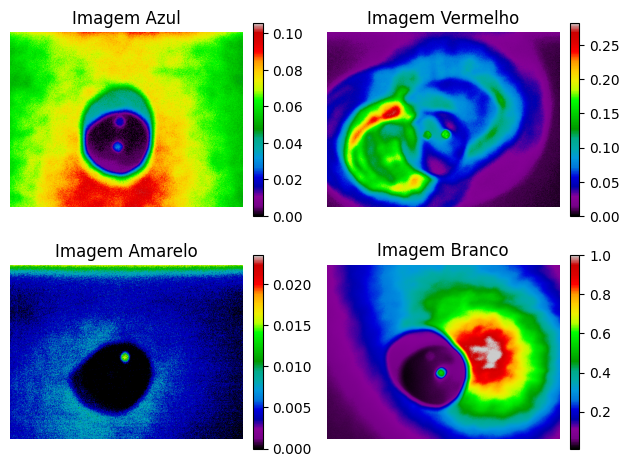

In [10]:
plt.subplot(2, 2, 1)
im1 = plt.imshow(image_blue, vmin=np.min(image_blue), vmax=np.max(image_blue))
plt.axis('off')
plt.title("Imagem Azul")
plt.colorbar(im1, fraction=0.046, pad=0.04)

plt.subplot(2, 2, 2)
im2 = plt.imshow(image_red, vmin=np.min(image_red), vmax=np.max(image_red))
plt.axis('off')
plt.title("Imagem Vermelho")
plt.colorbar(im2, fraction=0.046, pad=0.04)

plt.subplot(2, 2, 3)
im3 = plt.imshow(image_yellow, vmin=np.min(image_yellow), vmax=np.max(image_yellow))
plt.axis('off')
plt.title("Imagem Amarelo")
plt.colorbar(im3, fraction=0.046, pad=0.04)

plt.subplot(2, 2, 4)
im4 = plt.imshow(image_white, vmin=np.min(image_white), vmax=np.max(image_white))
plt.axis('off')
plt.title("Imagem Branco")
plt.colorbar(im4, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [7]:
rgb_image = np.dstack((image_blue, image_red, image_yellow))
rgb_image.shape

(480, 640, 3)

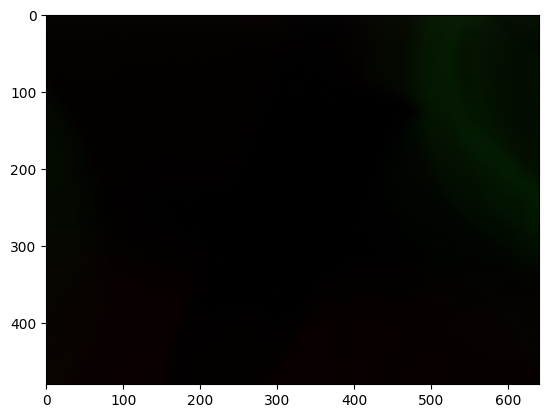

In [8]:
plt.set_cmap('viridis')
plt.imshow(rgb_image)

# Sample Segmentation

## Coin Example

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

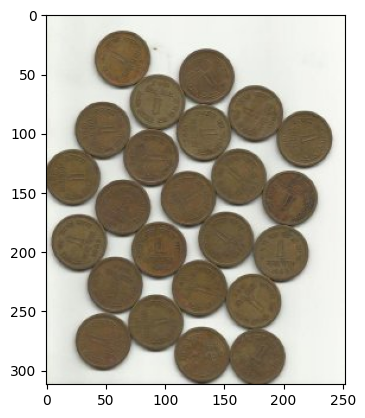

In [31]:
img = cv.imread('spectral_project/spectral_app/static/img/coins.png')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

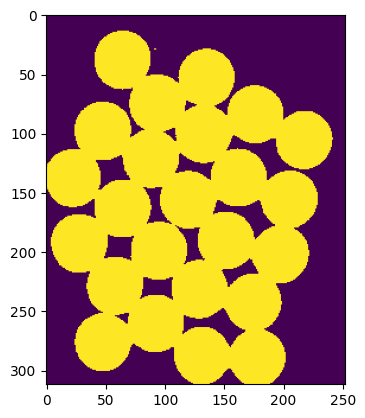

In [13]:
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
plt.imshow(thresh)

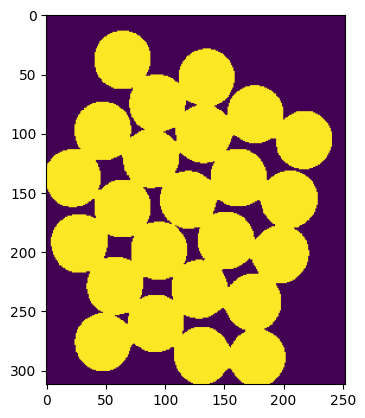

In [20]:
# noise removal --> Remove pequenos pontos brancos (ruído).
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
plt.imshow(opening)

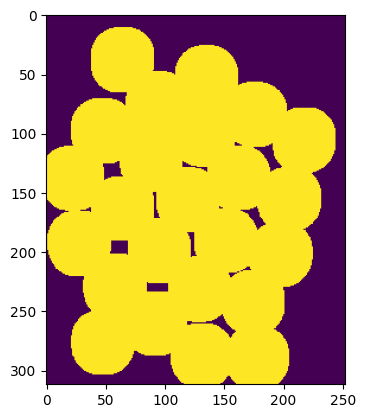

In [21]:
# sure background area 
sure_bg = cv.dilate(opening,kernel,iterations=3) # Isso expande as áreas brancas, garantindo que tudo que está marcado como fundo realmente é fundo seguro.
plt.imshow(sure_bg)

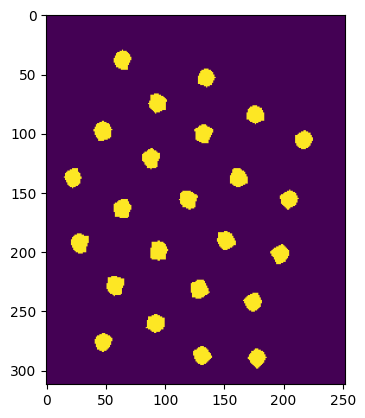

In [22]:
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5) # calcula, para cada pixel, a distância até o fundo mais próximo.
ret, sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0) # Isso pega apenas as regiões mais centrais de cada objeto, evitando incluir bordas ou ruídos
sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg)

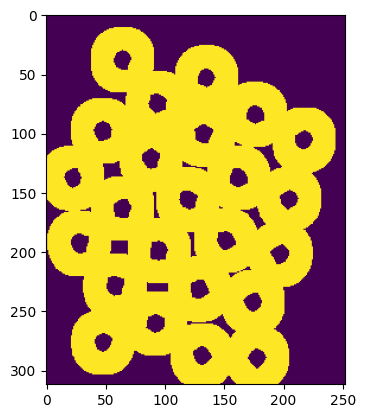

In [23]:
# Finding unknown region
unknown = cv.subtract(sure_bg,sure_fg)
plt.imshow(unknown)

In [33]:
# Marker labelling
ret, markers = cv.connectedComponents(sure_fg)
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
 
# Now, mark the region of unknown with zero
markers[unknown==255] = 0

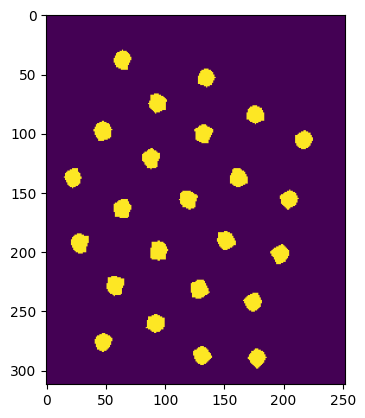

In [34]:
plt.imshow(sure_fg)

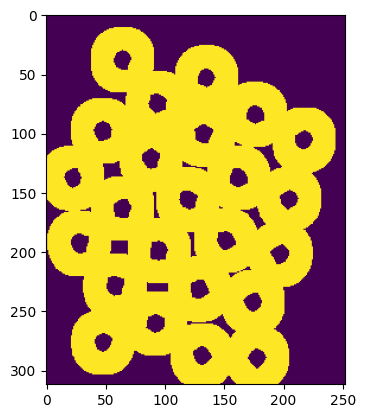

In [35]:
plt.imshow(unknown)

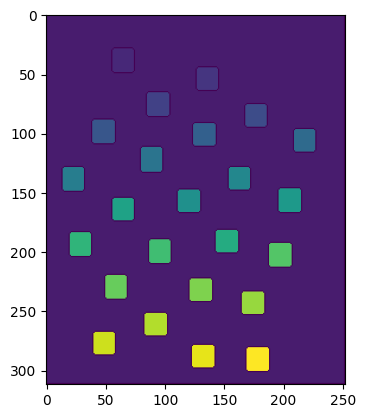

In [37]:
markers = cv.watershed(img,markers)
img[markers == -1] = [255,0,0]
plt.imshow(markers)

<function matplotlib.pyplot.show(close=None, block=None)>

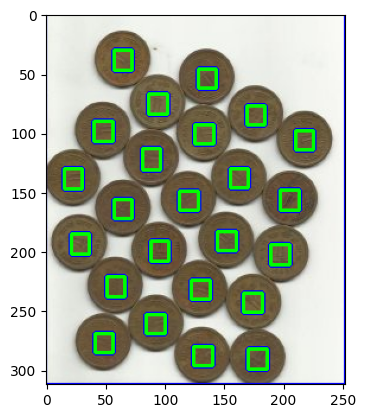

In [38]:
# Encontra contornos
contours, hierarchy = cv.findContours(sure_fg, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Desenha retângulos em volta de cada contorno
for cnt in contours:
    x, y, w, h = cv.boundingRect(cnt)  # coordenadas do retângulo
    cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # verde, espessura 2

# Mostra resultado
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show

## Beans 1

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

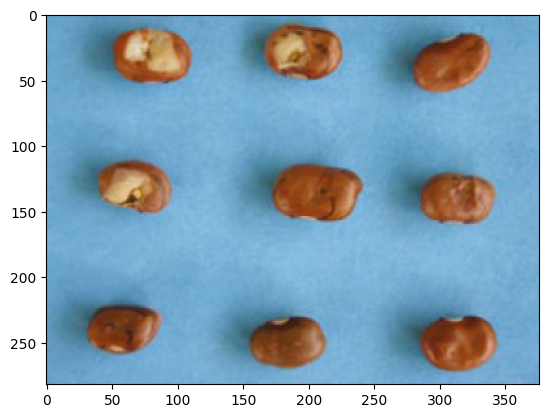

In [2]:
img = cv.imread('spectral_project/spectral_app/static/img/damaged_beans.png')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

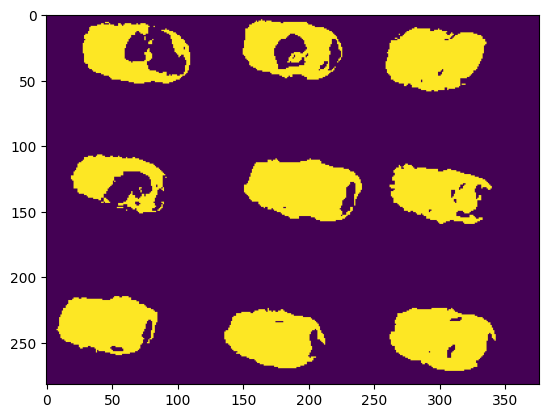

In [3]:
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
plt.imshow(thresh)

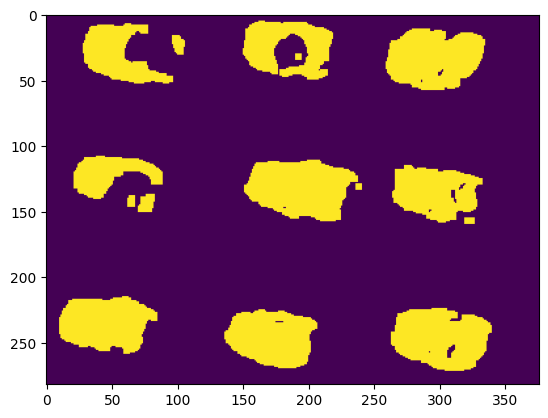

In [4]:
# noise removal --> Remove pequenos pontos brancos (ruído).
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
plt.imshow(opening)

1117.157894736842
2354.0


<function matplotlib.pyplot.show(close=None, block=None)>

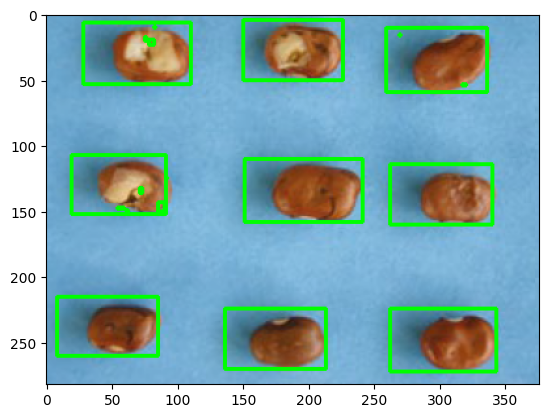

In [ ]:
# Encontra contornos
contours, hierarchy = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

contour_area_list = []
for countor in contours:
    contour_area_list.append(cv.contourArea(countor))
contour_mean = sum(contour_area_list) / len(contours) 
print(contour_mean)

# Pega só os 9 contornos maiores
# contours = sorted(contours, key=cv.contourArea, reverse=True)[:9]
print(cv.contourArea(contours[1]))

# Desenha retângulos em volta de cada contorno
for cnt in contours:
    x, y, w, h = cv.boundingRect(cnt)  # coordenadas do retângulo
    cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # verde, espessura 2

# Mostra resultado
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show

## Beans 2

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

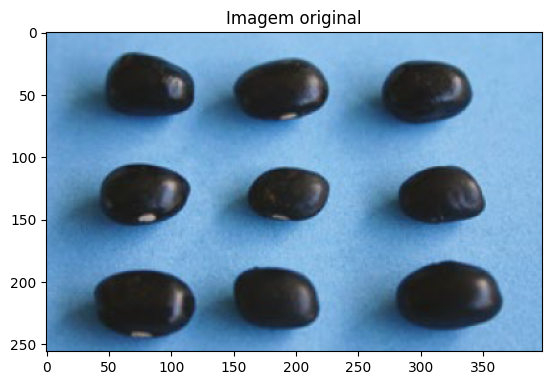

In [31]:
# Carrega a imagem
# img = cv.imread("spectral_project/spectral_app/static/img/damaged_beans.png")
img = cv.imread("spectral_project/spectral_app/static/img/beans.png")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Imagem original")
plt.show()

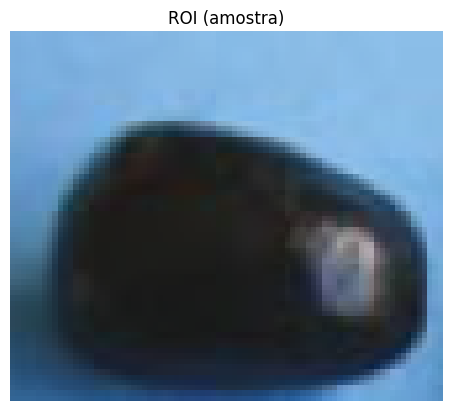

In [32]:
# Definir ROI manualmente (x, y, w, h)
x, y, w, h = 40, 0, 82, 70  
sample_base = img[y:y+h, x:x+w]

plt.imshow(cv.cvtColor(sample_base, cv.COLOR_BGR2RGB))
plt.title("ROI (amostra)")
plt.axis("off")
plt.show()

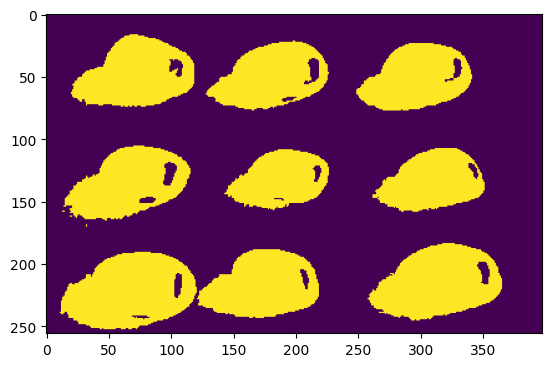

In [33]:
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
plt.imshow(thresh)

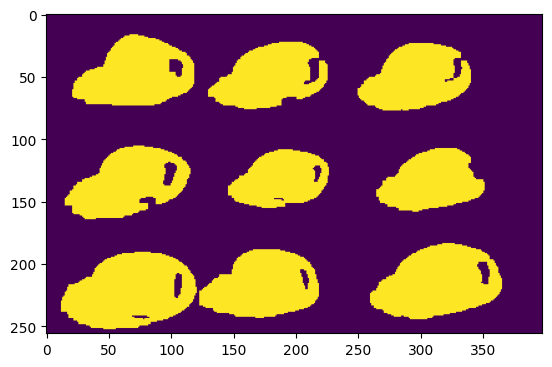

In [34]:
# noise removal --> Remove pequenos pontos brancos (ruído).
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
plt.imshow(opening)

<function matplotlib.pyplot.show(close=None, block=None)>

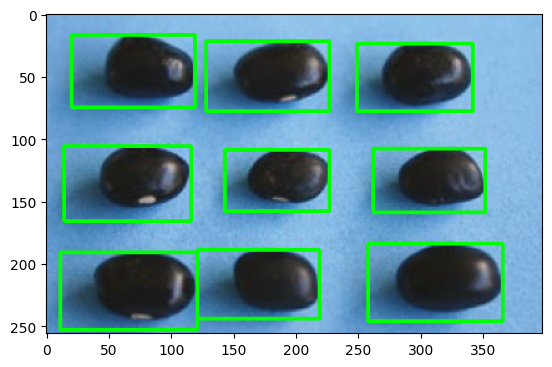

In [36]:
# Encontra contornos
# Condições de Contorno:
#   Passar o número de amostras
#   Fazer o contorno que permitirá que o algoritmo filtrar os contornos que possuam o tamanho semelhante ao selecionado, estou pensando em 10% para mais e para menos

# Define a quantidade de samples que serão analisadas
samples_quantity = input("How samples will be for each photo?")
sample_base_area = sample_base.shape[0] * sample_base.shape[1]
contours, hierarchy = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

contour_area_dict = {}
for i, contour in enumerate(contours):
    contour_area = cv.contourArea(contour)
    contour_area_dict[i] = {
        "contour": contour,
        "contour_area": contour_area,
        "difference_area_abs": abs(sample_base_area - contour_area)
    }

# Ordenando os contornos pelo menor difference_area_abs
sorted_items = sorted(
    contour_area_dict.values(), 
    key=lambda c: c["difference_area_abs"]
)

# Extraindo apenas os contornos em uma lista
sorted_contours_list = [c["contour"] for c in sorted_items]

# Desenha retângulos em volta de cada contorno e cria os crops
crops = []
for cnt in sorted_contours_list[:int(samples_quantity)]:
    x, y, w, h = cv.boundingRect(cnt)  # coordenadas do retângulo
    cv.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # verde, espessura 2

    # Extrair a região (crop) e armazenar na lista
    crop = opening[y:y+h, x:x+w]
    crops.append(crop)

# Mostra resultado
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show

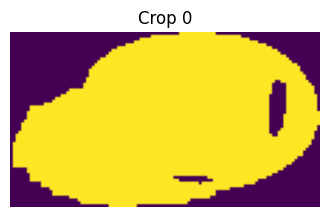

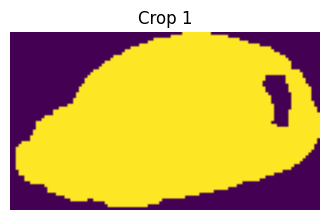

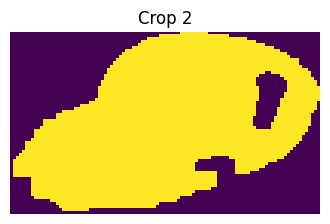

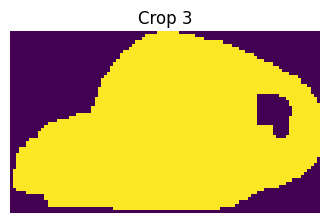

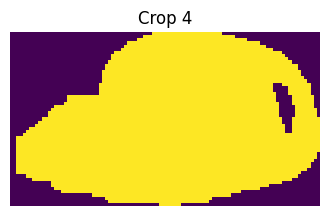

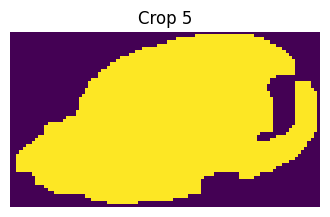

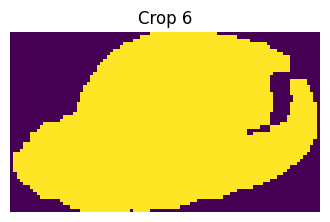

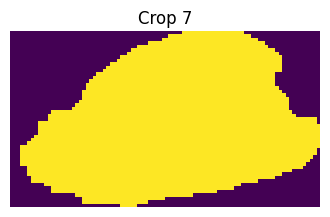

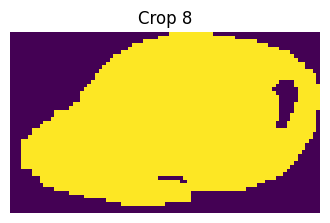

In [ ]:

for i, crop in enumerate(crops):
    plt.figure(figsize=(4, 4))
    plt.imshow(crop)
    plt.title(f"Crop {i}")
    plt.axis('off')
    plt.show()